<a href="https://colab.research.google.com/github/GiorgiaTrabucco/Capacitors/blob/main/Capacitors.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Capacitors
Read in the true C1–Ceq values and displace each C1 and Ceq by an offset randomly drawn from a Gaussian distribution centered in 0, with standard deviation 0.5. Save these C1–Ceq values in a textfile called offset.dat.


In [ ]:
# packages
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
from numpy import savetxt

In [ ]:
# useful constants
N = 1000
mu = 0
sigma = 0.5 * 10**-12 #F
#print(sigma)

In [ ]:
# file from which we read data
f = "true.dat"

In [ ]:
# store the data in a np array
data = np.loadtxt(f)

In [ ]:
#print(data)

In [ ]:
# divide the data

# capacity of the capacitor 1
C1 = data[:,0]
# equivalent capacity
Ceq = data[:,1]

In [ ]:
# we generate the displacememt
dis_C1 = np.random.normal(mu, sigma, N)
dis_Ceq = np.random.normal(mu, sigma, N)

# we add the displacememt to C1 and Ceq
C1_ = C1 + dis_C1;
Ceq_ = Ceq + dis_Ceq;

In [ ]:
# we create a new data nparray with all the data C1_ and Ceq_
data_ = np.column_stack([C1_, Ceq])
#print(data_)

In [ ]:
# We write data on the file
savetxt('offset.dat', data_, delimiter='\t')

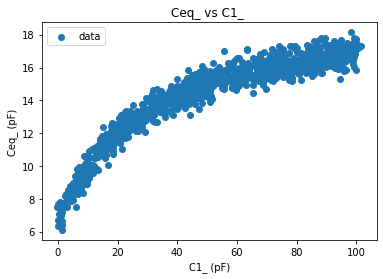

In [ ]:
# now we plot Ceq_ vs C1_
#I write x and y in pF
x = C1_ * 1e12
y = Ceq_ * 1e12


plt.scatter(x, y, label= "data")
#plt.plot(x, ys, label= "Fit function")
plt.title("Ceq_ vs C1_ ")
plt.xlabel('C1_ (pF)')
plt.ylabel('Ceq_ (pF)')
plt.legend()

In [ ]:
#we define the fit function
def fit_function(x, a, b):
	return 1/(1/(x + a) + b)

In [ ]:
# we can extrapolate a and b from the formula of the capacitors
a1 = 10
b1 = 0.05

In [ ]:
#we do the fit
popt, pcov = curve_fit(fit_function, x, y, p0 = [a1,b1])

In [ ]:
#I save the fitted points
xfit = np.copy(x)
xfit.sort()
yfit = fit_function(xfit, popt[0], popt[1])

print(popt[0], popt[1])

9.998110183842089 0.04999651222223446


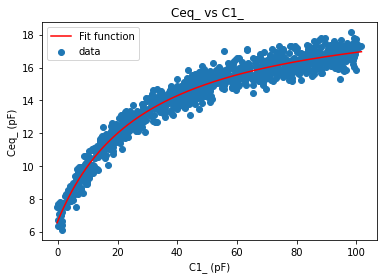

In [ ]:
#I plot data with the fit
plt.scatter(x, y, label= "data")
plt.plot(xfit, yfit, label= "Fit function", color = "red")
plt.title("Ceq_ vs C1_ ")
plt.xlabel('C1_ (pF)')
plt.ylabel('Ceq_ (pF)')
plt.legend()

Read in the true Ceq values and this time associate an error value ∆Ceq to each Ceq by randomly drawing from a Gaussian distribution centered in 0, with standard deviation 3. Save these values in the textfile errorbar.dat.

In [ ]:
# values of the Gaussian
sigma1 = 3 * 10**-12 #F

In [ ]:
# we generate the values on the gaussian
dCeq = np.random.normal(mu, sigma1, N)

In [ ]:
# we create a new data nparray with all the data Ceq and dCeq
data1 = np.column_stack([Ceq, dCeq])

In [ ]:
# We write data on the file
savetxt('errorbar.dat', data_, delimiter='\t')

In [ ]:
#now we do install the emcee package
!pip install pymc

In [ ]:
import pymc

/usr/local/lib/python3.7/dist-packages/statsmodels/tools/_testing.py:19: FutureWarning: pandas.util.testing is deprecated. Use the functions in the public API at pandas.testing instead.
  import pandas.util.testing as tm


In [ ]:
# Here we use the values in pF
x1 = x
y1 = Ceq * 1e12
dy1 = dCeq * 1e12
s1 = sigma * 1e12

In [ ]:
# Define the parameters with their associated priors
a = pymc.Uniform('a', 5, 15, value=a1)
b = pymc.Uniform('b', -1, 1, value=b1)

In [ ]:
# Now define the model
@pymc.deterministic
def model(a=a, b=b, x=x1):
    return 1/(1/(x + a) + b)

In [ ]:
# pymc parametrizes the width of the normal distribution by tau=1/sigma**2
@pymc.deterministic
def tau(yerr=dy1, model=model):
   return np.power(yerr, -2)

In [ ]:
# Lastly relate the model/parameters to the data
data = pymc.Normal('data', mu=model, tau=tau, value=y1, observed=True)

In [ ]:
nsampler = 20000
sampler = pymc.MCMC([a, b, model, dy1, y1, x1])
sampler.sample(iter=nsampler)

 [-----------------100%-----------------] 20000 of 20000 complete in 17.0 sec

Plotting a
Plotting b


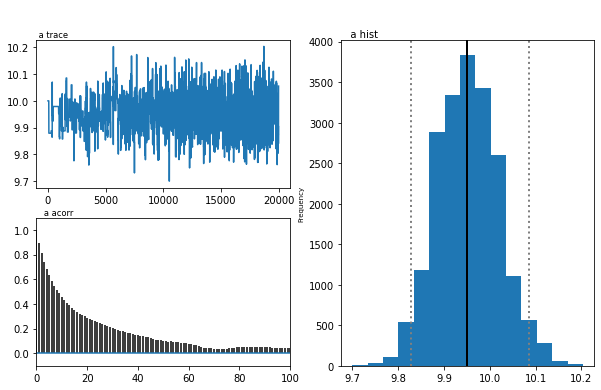

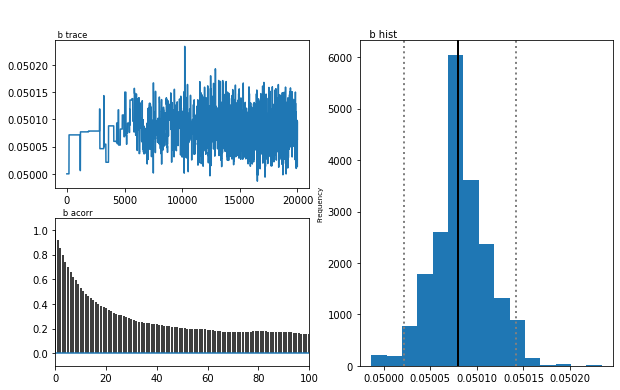

In [ ]:
pymc.Matplot.plot(sampler)

In [ ]:
a.summary()
b.summary()


a:
 
	Mean             SD               MC Error        95% HPD interval
	------------------------------------------------------------------
	9.952            0.067            0.003            [ 9.828 10.085]
	
	
	Posterior quantiles:
	
	2.5             25              50              75             97.5
	 |---------------|===============|===============|---------------|
	9.828            9.905           9.951          9.999         10.09
	

b:
 
	Mean             SD               MC Error        95% HPD interval
	------------------------------------------------------------------
	0.05             0.0              0.0                  [0.05 0.05]
	
	
	Posterior quantiles:
	
	2.5             25              50              75             97.5
	 |---------------|===============|===============|---------------|
	0.05             0.05            0.05           0.05          0.05
	
